## 26W-COM SCI-M148 Project 2 - Binary Classification Comparative Methods

Name: Gene Kung

UID: 305955388

### **Submission Guidelines (Due: Feb 23, at 4PM)**
1. Please fill in your name and UID above.

2. Please submit a **PDF printout** of this Jupyter Notebook and answer the correpsonding questions on **Gradescope**. If you have any trouble accessing Gradescope, please let a TA know ASAP.  

For this project we're going to attempt a binary classification of a dataset using multiple methods and compare results.

Our goals for this project will be to introduce you to several of the most common classification techniques, how to perform them and tweek parameters to optimize outcomes, how to produce and interpret results, and compare performance. You will be asked to analyze your findings and provide explanations for observed performance.

Specifically you will be asked to classify whether a <b>patient is suffering from heart disease</b> based on a host of potential medical factors.

<b><u>DEFINITIONS</b></u>


<b> Binary Classification:</b>
In this case a complex dataset has an added 'target' label with one of two options. Your learning algorithm will try to assign one of these labels to the data.

<b> Supervised Learning:</b>
This data is fully supervised, which means it's been fully labeled and we can trust the veracity of the labeling.

## Background: The Dataset

For this exercise, we will be using a subset of the <b>UCI Heart Disease dataset</b>. This dataset was created by collecting clinical data from patients undergoing diagnostic tests for heart disease. All identifying information about the patients has been removed to protect their privacy. The dataset represents data from patients who were suspected of having heart disease and underwent several diagnostic tests, including blood tests, electrocardiograms (ECG), exercise stress tests, and fluoroscopic imaging.

The dataset includes 14 columns. The information provided by each column is as follows:
<ul>
    <li><b>age:</b> Patient age in years</li>
    <li><b>sex:</b> Patient sex (1 = male; 0 = female)</li>
    <li><b>c_pain:</b> Chest pain type (0 = asymptomatic; 1 = atypical angina (unusual discomfort due to reduced blood flow to the heart); 2 = non-anginal pain (chest pain unrelated to the heart); 3 = typical angina (classic chest discomfort due to reduced blood flow to the heart))</li>
    <li><b>rbp:</b> Resting blood pressure in mm Hg (measured at hospital admission)</li>
    <li><b>chol:</b> Serum cholesterol level in mg/dL</li>
    <li><b>high_fbs:</b> Fasting blood sugar > 120 mg/dL (1 = true; 0 = false)</li>
    <li><b>r_ecg:</b> Resting electrocardiographic results (0 = probable thickened left ventricular wall; 1 = normal; 2 = ST-T wave abnormality)</li>
    <li><b>hr_max:</b> Maximum heart rate achieved during the stress test</li>
    <li><b>has_ex_ang:</b> Exercise-induced angina (1 = yes; 0 = no)</li>
    <li><b>ecg_depress:</b> Depression of the ST segment on ECG during exercise compared to rest (measured in mm)</li>
    <li><b>stress_slope:</b> Slope of the peak exercise ST segment (0 = downsloping (concerning); 1 = flat (abnormal); 2 = upsloping (normal))</li>
    <li><b>num_vessels:</b> Number of major vessels (0–3) showing good blood flow during fluoroscopy</li>
    <li><b>thal_test_res:</b> Thallium Stress Test result (assesses blood flow using trace amounts of radioactive thallium-201) (1 = normal; 2 = fixed defect; 7 = reversible defect)</li>
    <li><b>heart_disease:</b> Indicates whether heart disease is present (True = Disease; False = No disease)</li>
</ul>


## Loading Essentials and Helper Functions

In [88]:
#Here are a set of libraries we imported to complete this assignment.
#Feel free to use these or equivalent libraries for your implementation
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # this is used for the plot the graph
import os
import seaborn as sns # used for plot interactive graph.
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import sklearn.metrics.cluster as smc
from sklearn.model_selection import KFold


from matplotlib import pyplot
import itertools

%matplotlib inline

import random

random.seed(42)

## Part 1. Load the Data and Analyze

Let's first load our dataset so we'll be able to work with it. (correct the relative path if your notebook is in a different directory than the csv file.)

In [89]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/My Drive/CSM148/Assignment2/heartdisease.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Now that our data is loaded, let's take a closer look at the dataset we're working with. Use the head method,  the describe method, and the info method to display some of the rows so we can visualize the types of data fields we'll be working with.

In [90]:
data.head()

,age,sex,chest_pain,rpb,chol,high_fbs,r_ecg,hr_max,ex_ang,ecg_depress,stress_slope,num_vessels,thal_test_res,heart_disease
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,False
1,37,1,2,130,250,0,1,190,0,3.5,0,0,2,False
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,False
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,False
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,False


In [91]:
data.describe()

,age,sex,chest_pain,rpb,chol,high_fbs,r_ecg,hr_max,ex_ang,ecg_depress,stress_slope,num_vessels,thal_test_res
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.963696,131.435644,246.234323,0.148515,0.528053,149.551155,0.326733,1.039604,1.399340,0.729373,2.313531
std,9.082101,0.466011,1.023888,17.784257,51.842105,0.356198,0.525860,22.945585,0.469794,1.161075,0.616226,1.022606,0.612277
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    int64  
 1   sex            303 non-null    int64  
 2   chest_pain     303 non-null    int64  
 3   rpb            303 non-null    int64  
 4   chol           303 non-null    int64  
 5   high_fbs       303 non-null    int64  
 6   r_ecg          303 non-null    int64  
 7   hr_max         303 non-null    int64  
 8   ex_ang         303 non-null    int64  
 9   ecg_depress    303 non-null    float64
 10  stress_slope   303 non-null    int64  
 11  num_vessels    303 non-null    int64  
 12  thal_test_res  303 non-null    int64  
 13  heart_disease  303 non-null    bool   
dtypes: bool(1), float64(1), int64(12)
memory usage: 31.2 KB


### Before we begin our analysis we need to fix the field(s) that will be problematic. Specifically convert our boolean heart_disease variable into a binary numeric target variable (values of either '0' or '1', set True as '1'), and then drop the original heart_disease datafield from the dataframe. (hint: try label encoder or .astype())

In [93]:
data['heart_disease'] = data['heart_disease'].astype(int)
data.head()

,age,sex,chest_pain,rpb,chol,high_fbs,r_ecg,hr_max,ex_ang,ecg_depress,stress_slope,num_vessels,thal_test_res,heart_disease
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,0
1,37,1,2,130,250,0,1,190,0,3.5,0,0,2,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,0


### Now that we have a feel for the data-types for each of the variables, plot histograms of each field and attempt to ascertain how each variable performs (is it a binary, or limited selection, or does it follow a gradient?

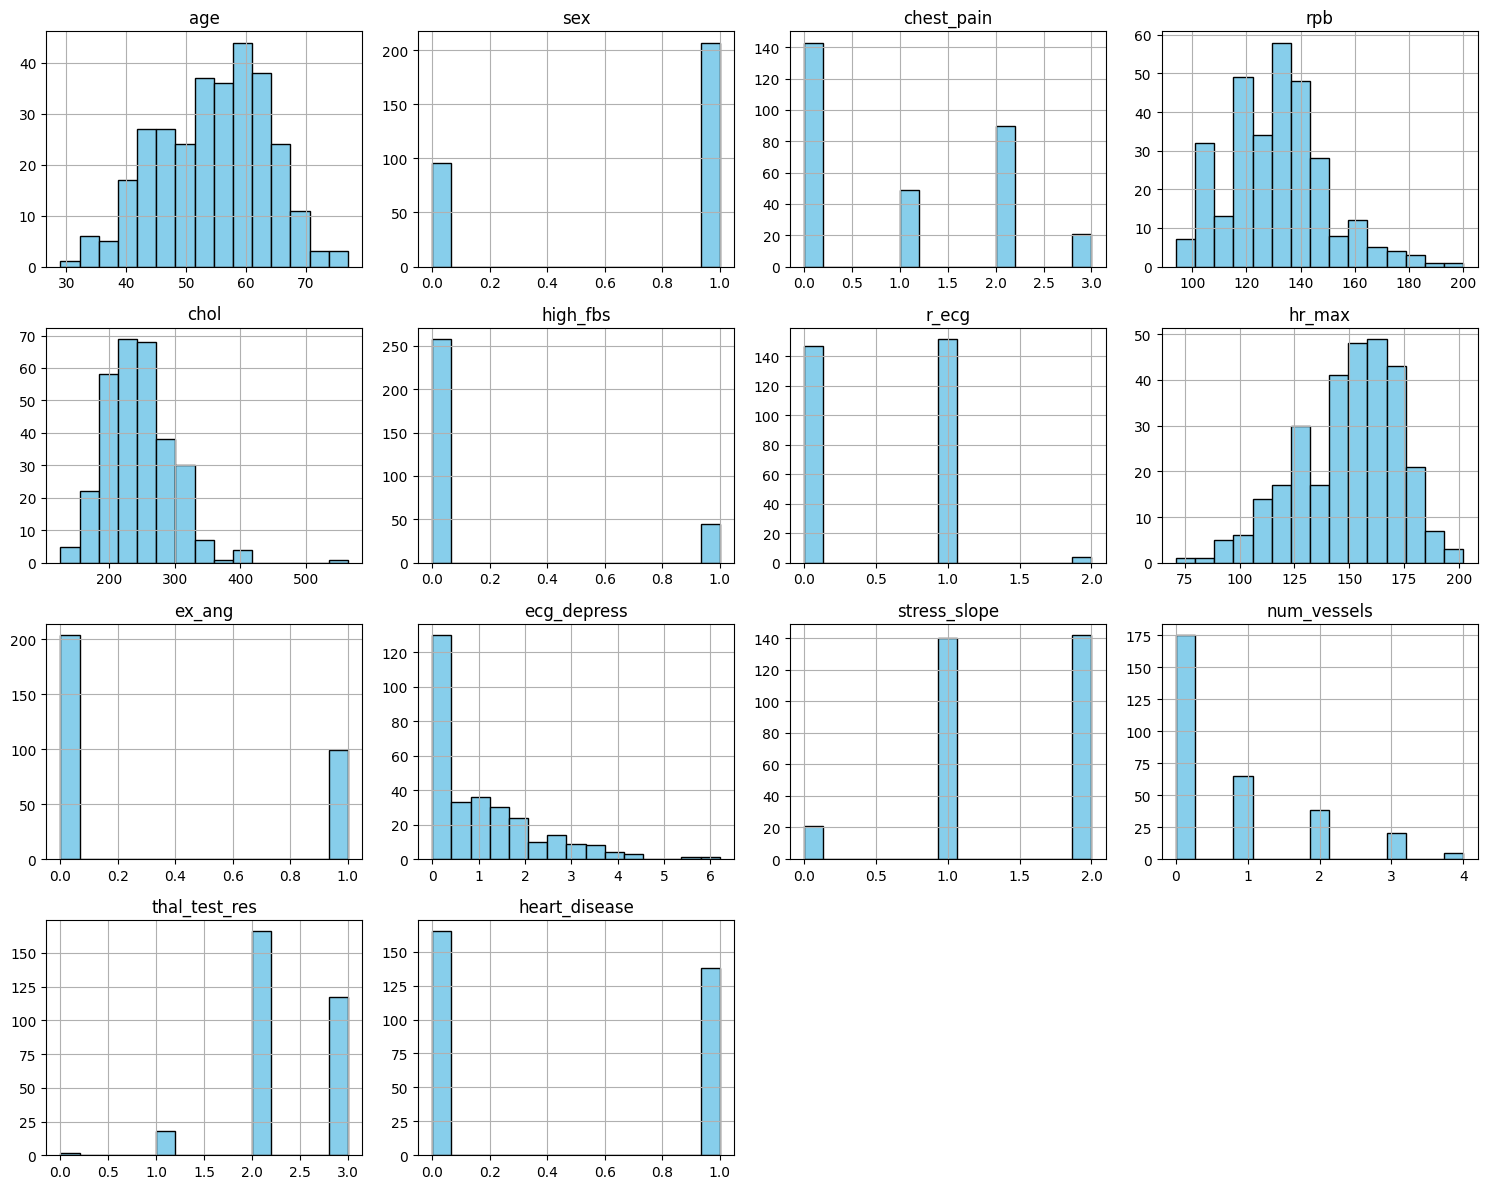

In [94]:
data.hist(figsize=(15, 12), bins=15, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

### We also want to make sure we are dealing with a balanced dataset. In this case, we want to confirm whether or not we have an equitable number of  sick and healthy individuals to ensure that our classifier will have a sufficiently balanced dataset to adequately classify the two. Plot a histogram specifically of the heart_disease target, and conduct a count of the number of diseased and healthy individuals and report on the results:

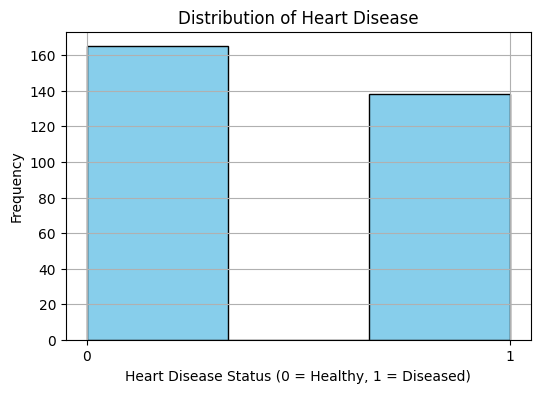

Count of Healthy (0) vs Diseased (1):
heart_disease
0    165
1    138
Name: count, dtype: int64


In [95]:
plt.figure(figsize=(6, 4))
data['heart_disease'].hist(bins=3, color='skyblue', edgecolor='black')
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease Status (0 = Healthy, 1 = Diseased)')
plt.ylabel('Frequency')
plt.xticks([0, 1])
plt.show()

disease_counts = data['heart_disease'].value_counts()
print("Count of Healthy (0) vs Diseased (1):")
print(disease_counts)

### Now that we have our dataframe prepared let's start analyzing our data. For this next question let's look at the correlations of our variables to our target value. First, map out the correlations between the values, and then discuss the relationships you observe. Do some research on the variables to understand why they may relate to the observed corellations. Intuitively, why do you think some variables correlate more highly than others (hint: one possible approach you can use the sns heatmap function to map the corr() method)?

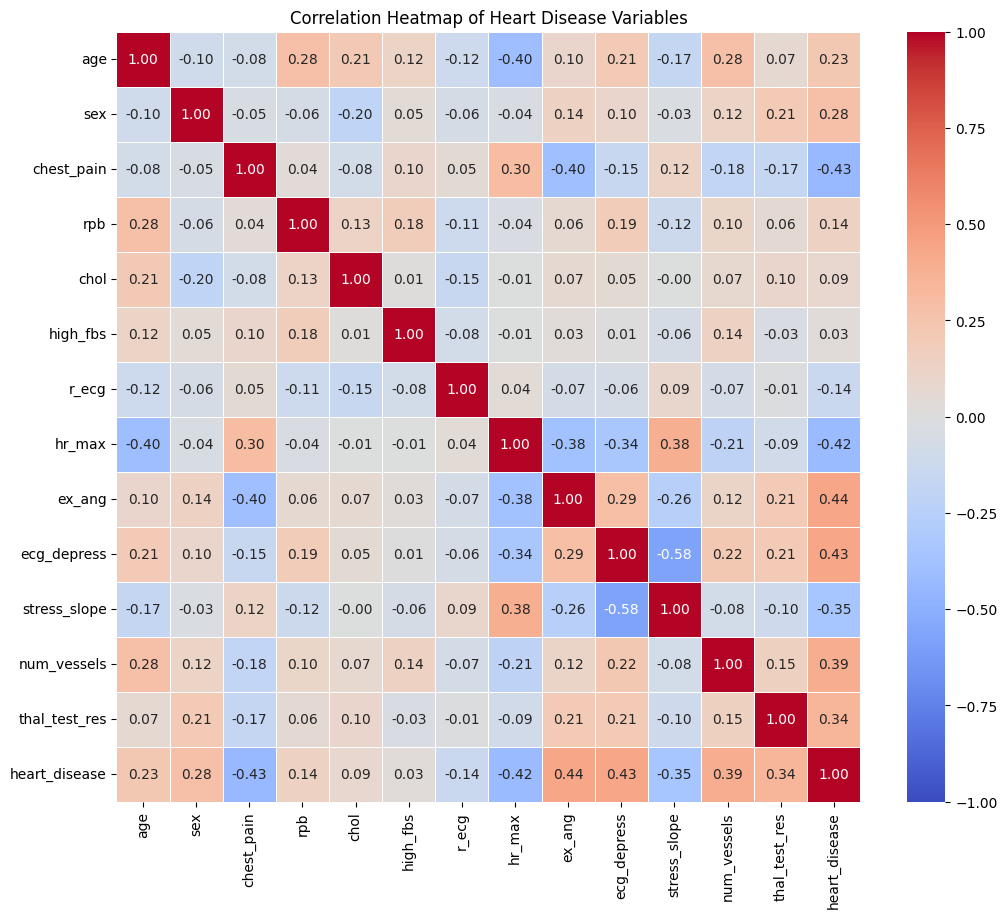

In [96]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Heart Disease Variables')
plt.show()

## Part 2. Prepare the 'Raw' Data and run a KNN Model

Before running our various learning methods, we need to do some additional prep to finalize our data. Specifically you'll have to cut the classification target from the data that will be used to classify, and then you'll have to divide the dataset into training and testing cohorts.

Specifically, we're going to ask you to prepare 2 batches of data: 1. Will simply be the raw numeric data that hasn't gone through any additional pre-processing. The other, will be data that you pipeline using your own selected methods. We will then feed both of these datasets into a classifier to showcase just how important this step can be!

### Save the label column as a separate array and then drop it from the dataframe.

In [97]:
y = data['heart_disease'].values
X = data.drop('heart_disease', axis=1)

### First Create your 'Raw' unprocessed training data by dividing your dataframe into training and testing cohorts, with your training cohort consisting of 70% of your total dataframe (hint: use the train_test_split() method) Output the resulting shapes of your training and testing samples to confirm that your split was successful.

In [98]:
# using random_state=42 for the splitting and all the models to ensure reproducibility of results

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

### We'll explore how not processing your data can impact model performance by using the K-Nearest Neighbor classifier. One thing to note was because KNN's rely on Euclidean distance, they are highly sensitive to the relative magnitude of different features. Let's see that in action! Implement a K-Nearest Neighbor algorithm on our raw data and report the results. For this initial implementation simply use the **default** settings. Refer to the [KNN Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) for details on implementation. Report on the accuracy of the resulting model.

In [100]:
knn_raw = KNeighborsClassifier()
knn_raw.fit(X_train, y_train)

y_pred_raw = knn_raw.predict(X_test)

In [101]:
raw_accuracy = metrics.accuracy_score(y_test, y_pred_raw)
print(f"Accuracy of KNN on Raw Data: {raw_accuracy:.4f}")

Accuracy of KNN on Raw Data: 0.6703


### Now implement a pipeline of your choice. You can opt to handle categoricals however you wish, however please scale your numeric features using standard scaler. Use the fit_transform() to fit this pipeline to your training data. and then transform() to apply that pipeline to your test data

Hint:
1. Create separate pipelines for numeric and categorical features with Pipeline() and then combining them with ColumnTransformer()
2. First, fit the full pipeline with the training data. Then, apply it to the test data as well.

Note:
- Numerical features: "age", "rpb", "chol", "hr_max", "ecg_depress"
- Categorical features: "sex", "chest_pain", "high_fbs", "r_ecg", "ex_ang", "stress_slope", "num_vessels", "thal_test_res"

### Pipeline:

In [102]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer

In [103]:
# Create pipelines
numeric_features = ["age", "rpb", "chol", "hr_max", "ecg_depress"]
categorical_features = ["sex", "chest_pain", "high_fbs", "r_ecg", "ex_ang", "stress_slope", "num_vessels", "thal_test_res"]

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [104]:
# Pipeline the training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Now retrain your model and compare the accuracy metrics (Accuracy, Precision, Recall, F1 Score) with the raw and pipelined data.

In [105]:
# KNN
knn_pipelined = KNeighborsClassifier()
knn_pipelined.fit(X_train_processed, y_train)

y_pred_pipelined = knn_pipelined.predict(X_test_processed)

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Report Metrics
acc_raw = accuracy_score(y_test, y_pred_raw)
prec_raw = precision_score(y_test, y_pred_raw)
rec_raw = recall_score(y_test, y_pred_raw)
f1_raw = f1_score(y_test, y_pred_raw)
print("--- KNN on Raw Data ---")
print(f"Accuracy:  {acc_raw:.4f}")
print(f"Precision: {prec_raw:.4f}")
print(f"Recall:    {rec_raw:.4f}")
print(f"F1 Score:  {f1_raw:.4f}\n")

acc_pipelined = accuracy_score(y_test, y_pred_pipelined)
prec_pipelined = precision_score(y_test, y_pred_pipelined)
rec_pipelined = recall_score(y_test, y_pred_pipelined)
f1_pipelined = f1_score(y_test, y_pred_pipelined)
print("--- KNN on Pipelined Data ---")
print(f"Accuracy:  {acc_pipelined:.4f}")
print(f"Precision: {prec_pipelined:.4f}")
print(f"Recall:    {rec_pipelined:.4f}")
print(f"F1 Score:  {f1_pipelined:.4f}")

--- KNN on Raw Data ---
Accuracy:  0.6703
Precision: 0.6486
Recall:    0.5854
F1 Score:  0.6154

--- KNN on Pipelined Data ---
Accuracy:  0.8681
Precision: 0.8537
Recall:    0.8537
F1 Score:  0.8537


[Discuss Results here]

Processing the data with our pipeline resulted in a massive improvement across all the metrics. Accuracy jumped from 67% to 87%, and the F1 Score (which may be a better metric than accuracy in certain cases) improved from 0.61 to 0.85. Because the K-Nearest Neighbors algorithm relies on calculating the physical Euclidean distance between data points, it is highly sensitive to the scale of the features, so this is why we see worse metrics when we don't standardize our data with the pipeline.

### Parameter Optimization.  The KNN Algorithm includes an n_neighbors attribute that specifies how many neighbors to use when developing the cluster. (The default value is 5, which is what your previous model used.) Lets now try n values of: 1, 2, 3, 5, 7, 9, 10, 20, and 50. Run your model for each value and report the accuracy for each. (HINT leverage python's ability to loop to run through the array and generate results without needing to manually code each iteration).

In [107]:
n_values = [1, 2, 3, 5, 7, 9, 10, 20, 50]
for n in n_values:
    knn_tuned = KNeighborsClassifier(n_neighbors=n)
    knn_tuned.fit(X_train_processed, y_train)

    y_pred_tuned = knn_tuned.predict(X_test_processed)

    acc = accuracy_score(y_test, y_pred_tuned)
    print(f"n_neighbors = {n:2d} | Accuracy: {acc:.4f}")

n_neighbors =  1 | Accuracy: 0.7582
n_neighbors =  2 | Accuracy: 0.7802
n_neighbors =  3 | Accuracy: 0.8242
n_neighbors =  5 | Accuracy: 0.8681
n_neighbors =  7 | Accuracy: 0.8681
n_neighbors =  9 | Accuracy: 0.8462
n_neighbors = 10 | Accuracy: 0.8462
n_neighbors = 20 | Accuracy: 0.8901
n_neighbors = 50 | Accuracy: 0.8571


## Part 3. Additional Learning Methods

So we have a model that seems to work well. But let's see if we can do better! To do so we'll employ multiple learning methods and compare result.

### Linear Decision Boundary Methods

### Logistic Regression

Let's now try another classifier,one that's well known for handling linear models: Logistic Regression. Logistic regression is a statistical model that in its basic form uses a logistic function to model a binary dependent variable.

### Implement a Logistical Regression Classifier. Review the [Logistical Regression Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for how to implement the model.

### Report metrics for:
1.   Accuracy
2.   Precision
3.   Recall
4.   F1 Score



In [108]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_processed, y_train)

y_pred_log = log_reg.predict(X_test_processed)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("--- Logistic Regression Metrics ---")
print(f"Accuracy:  {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall:    {rec_log:.4f}")
print(f"F1 Score:  {f1_log:.4f}")

--- Logistic Regression Metrics ---
Accuracy:  0.8681
Precision: 0.8718
Recall:    0.8293
F1 Score:  0.8500


### Discuss what each measure is reporting, why they are different, and why are each of these measures is significant. Explore why we might choose to evaluate the performance of differing models differently based on these factors. Try to give some specific examples of scenarios in which you might value one of these measures over the others.

[Provide explanation for each measure here]

- Accuracy basically just reports the total predictions the model got right i.e. (TP + TN)/Total Predictions. It gives us a quick highlevel overview of how well the model is generally performing. However, it is only best used as a metric when the dataset is perfectly balanced and the cost of making a false psoitivte is the same as making a false negative. For example, if we have an image classifer to predict if an image is a dog or cat, accuracy can be used to evaluate the model.
- Precision, in this case, basically predicts out of all the pateints the model labeled to have heart disease, how many actually had it i.e. (TP) / (TP + FP). This means it measures the quality of positive predictions and penalizes the model for false positivtes. We use this when a false positive is costly. For example, if we had an eamil spam filter, it would be very costly if a very important email is incorrectly classified as spam, so in this case we would want a model that focuses on precision.
- Recall says out of all the patients who actually have heart disease, how many did the model successfully find i.e. (TP) / (TP + FN). It measures the model to catch positive instances and penalizes it for false negatives. We focus on recall when a false negative is costly. For example, if the model labels a sick pateint as healthy and then sending them home without treatment, this is very costly.
- F1 score is basically just a balance between precision and recall i.e. 2 * (P * R) / (P + R). Since precision and recall can go against each other, F1 score gives you a single number to balance both. We generally use F1 score when the dataset is imbalanced or when you need a compromoise between minimizing FP and FN.

In our case, our model has slightly higher precision 87% than recall 82%. This means that when our logistic regression model predicts someone has heart disease, it's usually right but still has false negatives.


### Let's tweak a few settings. First let's set your solver to 'sag' (Stochastic Average Gradient), your max_iter= 10, and set penalty = None and rerun your model. Let's see how your results change!

In [109]:
log_reg_sag = LogisticRegression(solver='sag', max_iter=10, penalty=None, random_state=42)
log_reg_sag.fit(X_train_processed, y_train)

y_pred_sag = log_reg_sag.predict(X_test_processed)

acc_sag = accuracy_score(y_test, y_pred_sag)
prec_sag = precision_score(y_test, y_pred_sag)
rec_sag = recall_score(y_test, y_pred_sag)
f1_sag = f1_score(y_test, y_pred_sag)
print("--- Logistic Regression (solver='sag', max_iter=10, penalty=None) ---")
print(f"Accuracy:  {acc_sag:.4f}")
print(f"Precision: {prec_sag:.4f}")
print(f"Recall:    {rec_sag:.4f}")
print(f"F1 Score:  {f1_sag:.4f}")

--- Logistic Regression (solver='sag', max_iter=10, penalty=None) ---
Accuracy:  0.8571
Precision: 0.8500
Recall:    0.8293
F1 Score:  0.8395


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Did you notice that when you ran the previous model you got the following warning: "ConvergenceWarning: The max_iter was reached which means the coef_ did not converge". Check the documentation and see if you can implement a fix for this problem, and again report your results.

In [110]:
log_reg_sag_fixed = LogisticRegression(solver='sag', max_iter=5000, penalty=None, random_state=42)
log_reg_sag_fixed.fit(X_train_processed, y_train)

y_pred_sag_fixed = log_reg_sag_fixed.predict(X_test_processed)

acc_sag_fixed = accuracy_score(y_test, y_pred_sag_fixed)
prec_sag_fixed = precision_score(y_test, y_pred_sag_fixed)
rec_sag_fixed = recall_score(y_test, y_pred_sag_fixed)
f1_sag_fixed = f1_score(y_test, y_pred_sag_fixed)
print("--- Logistic Regression (Fixed: solver='sag', max_iter=5000, penalty=None) ---")
print(f"Accuracy:  {acc_sag_fixed:.4f}")
print(f"Precision: {prec_sag_fixed:.4f}")
print(f"Recall:    {rec_sag_fixed:.4f}")
print(f"F1 Score:  {f1_sag_fixed:.4f}")

--- Logistic Regression (Fixed: solver='sag', max_iter=5000, penalty=None) ---
Accuracy:  0.8352
Precision: 0.8250
Recall:    0.8049
F1 Score:  0.8148


### Explain what you changed, and why do you think that may have altered the outcome.

[Provide explanation here]
I increased the max_iter param from 10 to 5000. This changed the outcome because when we use SAG, we are trying to find the minimum error for the loss function. It does this by taking steps down a slope to find that minimum. At the minimum, i.e. the best weights for our feature with lowest loss, we have found the convergence point. Since we initially restricted max_iter to 10, we are forcing SAG to stop only after 10 steps, and when we see the convergence warning, it indicates we didn't find the minimum for the most optimal weights. We can simply resolve this for the model to actually find the convergence by increasing max_iter to a greater number. This ensures SAG will find the minimum and thus the optimal weights for the model.

### Rerun your logistic classifier, but modify the penalty = 'l1', solver='liblinear' and again report the results.

In [111]:
log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
log_reg_l1.fit(X_train_processed, y_train)

y_pred_l1 = log_reg_l1.predict(X_test_processed)

acc_l1 = accuracy_score(y_test, y_pred_l1)
prec_l1 = precision_score(y_test, y_pred_l1)
rec_l1 = recall_score(y_test, y_pred_l1)
f1_l1 = f1_score(y_test, y_pred_l1)
print("--- Logistic Regression (penalty='l1', solver='liblinear') ---")
print(f"Accuracy:  {acc_l1:.4f}")
print(f"Precision: {prec_l1:.4f}")
print(f"Recall:    {rec_l1:.4f}")
print(f"F1 Score:  {f1_l1:.4f}")

--- Logistic Regression (penalty='l1', solver='liblinear') ---
Accuracy:  0.8571
Precision: 0.8684
Recall:    0.8049
F1 Score:  0.8354


### Explain what the two solver approaches are, and why liblinear may have produced an improved outcome (but not always, and it's ok if your results show otherwise!).

[Provide explanation here]
- SAG, basically just a variation of gradient descent, handles optimization by using previous gradient steps to find the minimum faster. It is best used for large datasets where calculating the gradient at every single step could be computationally expensive/slow.
- liblinear uses a coordinate descent algorithim. Basically, instead of moving in the direction of steepest slope step (SAG), it optimizes one feature weight at a time. It is better for small datasets.
- liblinear produced a better outcome with our dataset because we are dealing with a pretty small dataset with 303 samples.

### SVM (Support Vector Machine)

A Support Vector Machine (SVM) is a discriminative classifier formally defined by a separating hyperplane. In other words, given labeled training data (supervised learning), the algorithm outputs an optimal hyperplane which categorizes new examples. In two dimentional space this hyperplane is a line dividing a plane in two parts where in each class lay in either side.

More explanation here: https://en.wikipedia.org/wiki/Support_vector_machine.

For the sake of this project, you can regard it as a type of classifier.

### Implement a Support Vector Machine classifier on your pipelined data. Review the [SVM Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) for how to implement a model. For this implementation you can simply use the default settings, but set probability = True.

In [112]:
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_processed, y_train)

y_pred_svm = svm_model.predict(X_test_processed)

### Report the accuracy, precision, recall, F1 Score, of your model, but in addition, plot a Confusion Matrix of your model's performance

recommend using `from sklearn.metrics import ConfusionMatrixDisplay` for this one!


In [113]:
# Report Metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
print("--- SVM Metrics (Default RBF Kernel) ---")
print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1 Score:  {f1_svm:.4f}")

--- SVM Metrics (Default RBF Kernel) ---
Accuracy:  0.8681
Precision: 0.8372
Recall:    0.8780
F1 Score:  0.8571


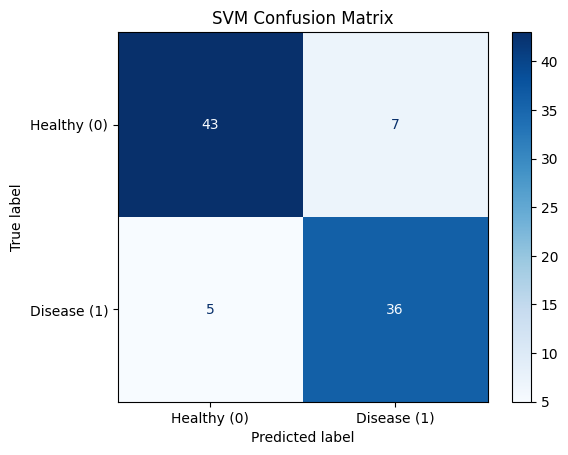

In [114]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy (0)", "Disease (1)"])

disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.show()

### Plot a Receiver Operating Characteristic curve, or ROC curve, and describe what it is and what the results indicate

recommend using the `metrics.roc_curve` `metrics.auc` and `metrics.RocCurveDisplay` for this one!
Note: use `svm.predict_proba` to get the probabilities of possible outcomes for samples in X instead of directly
use predictions for plotting ROC

<Figure size 800x600 with 0 Axes>

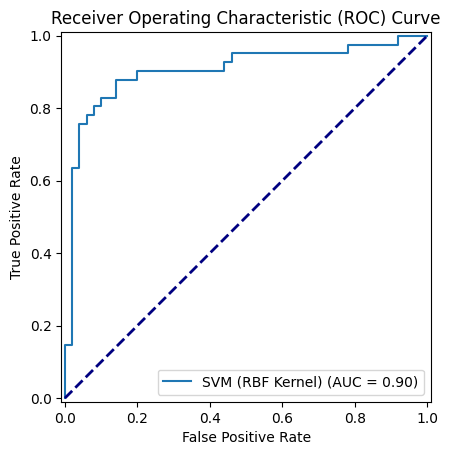

In [115]:
# ROC
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

y_score_svm = svm_model.predict_proba(X_test_processed)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='SVM (RBF Kernel)')
display.plot()

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

[Describe what an ROC Curve is and what the results mean here] The ROC curve is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at various threshold settings. The area under an ROC curve is a measure of the usefulness of a test in general, where a greater area means a more useful test, so the areas under ROC curves are used to compare the usefulness of tests. Here we see a relatively HIGH area under the curve indicating a STRONGLY performing model. Further, we have an AUC score of .90 which means there is a 90% chance the model will be able to distinguish between a pateint with heart disease and one without, further indicating how we have a strong SVM model.

### Rerun your SVM, but now modify your model parameter kernel to equal 'linear'. Again report your Accuracy, Precision, Recall, F1 scores, and Confusion matrix and plot the new ROC curve.  

In [116]:
# Metrics
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_processed, y_train)

y_pred_linear = svm_linear.predict(X_test_processed)

acc_lin = accuracy_score(y_test, y_pred_linear)
prec_lin = precision_score(y_test, y_pred_linear)
rec_lin = recall_score(y_test, y_pred_linear)
f1_lin = f1_score(y_test, y_pred_linear)
print("--- SVM Metrics (Linear Kernel) ---")
print(f"Accuracy:  {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall:    {rec_lin:.4f}")
print(f"F1 Score:  {f1_lin:.4f}")

--- SVM Metrics (Linear Kernel) ---
Accuracy:  0.8462
Precision: 0.8462
Recall:    0.8049
F1 Score:  0.8250


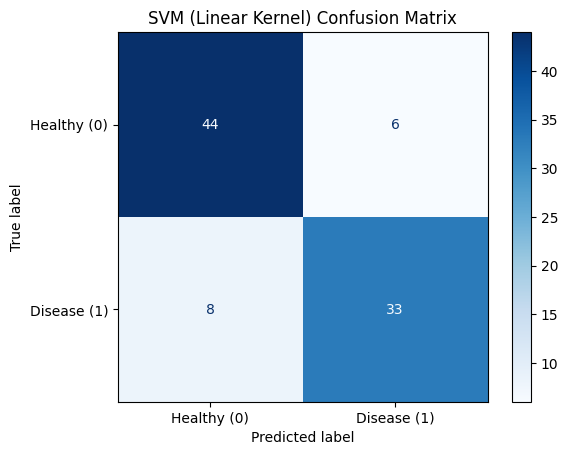

In [117]:
# Confusion Matrix
cm_lin = confusion_matrix(y_test, y_pred_linear)
disp_lin = ConfusionMatrixDisplay(confusion_matrix=cm_lin, display_labels=["Healthy (0)", "Disease (1)"])
disp_lin.plot(cmap=plt.cm.Blues)
plt.title("SVM (Linear Kernel) Confusion Matrix")
plt.show()

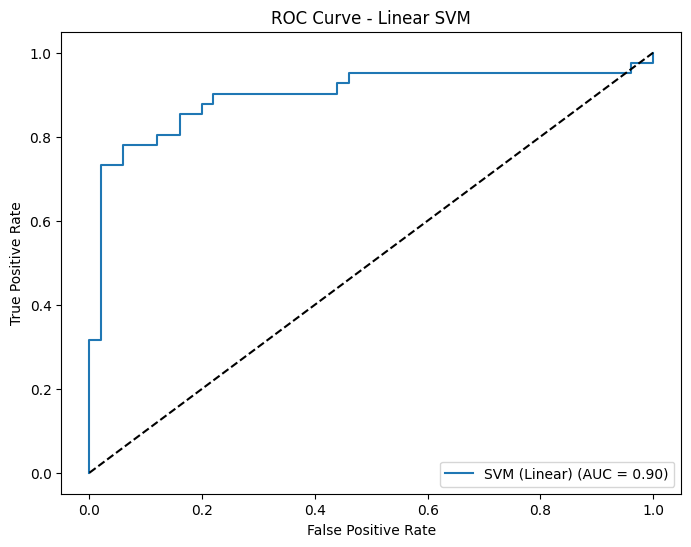

In [118]:
# ROC
y_score_lin = svm_linear.predict_proba(X_test_processed)[:, 1]
fpr_lin, tpr_lin, _ = roc_curve(y_test, y_score_lin)
roc_auc_lin = auc(fpr_lin, tpr_lin)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lin, tpr_lin, label=f'SVM (Linear) (AUC = {roc_auc_lin:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Linear SVM')
plt.legend(loc="lower right")
plt.show()

### Explain the what the new results you've achieved mean. Read the documentation to understand what you've changed about your model and explain why changing that input parameter might impact the results in the manner you've observed.

[Provide Answer here:]
- The linear SVM had an accuracy of 84% and an AUC of 0.90. The model has 44 TN (i.e. it correctly identified 44 healthy patients) and 33 TP (i.e. it correctly identified 33 patients with heart disease) and 8 FN (i.e. it missed 8 sick patients) and 6 FP (i.e. it incorrectly labeled 6 healthy patients as having disease).
- The kernel parameter in the SVM model determines the shape of the decision boundary used to separate the classes. With an RBF (default) the kernel uses radial bias functions to create complex and non-linear boundaries. However, with kernel=linear, we basically made the model find the best linear decision boundary that separates the classes.
- Thus, the parameter changed our results because since we used a linear decision boundary, the accuracy was decreased slightly, suggesting that the relationship between features is not perfectly linear with classifying disease. However, there is a tradeoff with the reduced complexity because it also means even though we used the linear decision boundary, we are doing less overfitting. Further, because our AUC remains 0.90, this means the primary correlators of heart disease are still powerful enough that a simple linear boundary can correctly classify most cases.

### Decision Trees

Create both a Decision Tree and a KNN and fit them onto your fully preprocessed data, then calculate an accuracy score for both (https://scikit-learn.org/stable/api/sklearn.tree.html).

### What are Decision Trees?

Decision Trees are a non-parametric supervised learning methods used for classification and regression. The goal is to split data into branches based on feature conditions, forming a tree-like structure where each internal node represents a decision, and each branch represents an outcome.

Compared to KNN, decision trees is less influenced by the high dimensionality of the data, and can make the model output more predicable.

For more explanation, see here: https://en.wikipedia.org/wiki/Decision_tree. For the sake of this project, you can regard it as a type of classifier.

In [119]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)

# KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)

In [120]:
# Decision Tree Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

# KNN Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy:           {knn_accuracy:.4f}")

Decision Tree Accuracy: 0.7143
KNN Accuracy:           0.8681


#### Categorical Preprocessing Only

Create a new preprocessing pipeline which ONLY preprocesses categorical values (leaving scalar variables in the data as they were originally, ie. no StandardScaler).   
Process your data with this new pipeline, fit a decision tree and a KNN once more and report a new accuracy score for each.   

Hint: Ensure that remainder = 'passthrough' in your ColumnTransformer to ensure scalar values are not dropped!    

In [121]:
# Categorical Preprocessing Only
cat_only_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

X_train_cat_only = cat_only_preprocessor.fit_transform(X_train)
X_test_cat_only = cat_only_preprocessor.transform(X_test)

In [122]:
# Fit Decision Tree
dt_cat_only = DecisionTreeClassifier(random_state=42)
dt_cat_only.fit(X_train_cat_only, y_train)

# Fit KNN
knn_cat_only = KNeighborsClassifier()
knn_cat_only.fit(X_train_cat_only, y_train)

KNeighborsClassifier()

In [123]:
# Decision Tree Accuracy
dt_acc_cat = accuracy_score(y_test, dt_cat_only.predict(X_test_cat_only))
print(f"Decision Tree Accuracy (Cat-only): {dt_acc_cat:.4f}")

# KNN Accuracy
knn_acc_cat = accuracy_score(y_test, knn_cat_only.predict(X_test_cat_only))
print(f"KNN Accuracy (Cat-only):           {knn_acc_cat:.4f}")

Decision Tree Accuracy (Cat-only): 0.7473
KNN Accuracy (Cat-only):           0.6703


# Printing Jupyter notebook to PDF (Google Colab Only, Optional)

It may take a few minutes to run

In [124]:
def colab2pdf():
  ENABLE=True # @param {type:"boolean"}
  if ENABLE:
    !apt-get install librsvg2-bin
    import os, datetime, json, locale, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions").json()[0]["name"])))
    TEMP = pathlib.Path("/content/pdfs") / f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{NAME.stem}"; TEMP.mkdir(parents=True, exist_ok=True)
    NB = [cell for cell in nbformat.reads(json.dumps(google.colab._message.blocking_request("get_ipynb", timeout_sec=600)["ipynb"]), as_version=4).cells if "--Colab2PDF" not in cell.source]
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    with (TEMP / f"{NAME.stem}.ipynb").open("w", encoding="utf-8") as nb_copy: nbformat.write(nbformat.v4.new_notebook(cells=NB or [nbformat.v4.new_code_cell("#")]), nb_copy)
  if not pathlib.Path("/usr/local/bin/quarto").exists():
    !wget -q "https://quarto.org/download/latest/quarto-linux-amd64.deb" -P {TEMP} && dpkg -i {TEMP}/quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet
    with (TEMP / "config.yml").open("w", encoding="utf-8") as file: yaml.dump({'include-in-header': [{"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}],'include-before-body': [{"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}]}, file)
    !quarto render {TEMP}/{NAME.stem}.ipynb --metadata-file={TEMP}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
    google.colab.files.download(str(TEMP / f"{NAME.stem}.pdf"))
colab2pdf()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  librsvg2-bin
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 1,871 kB of archives.
After this operation, 6,019 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 librsvg2-bin amd64 2.52.5+dfsg-3ubuntu0.2 [1,871 kB]
Fetched 1,871 kB in 1s (1,412 kB/s)
Selecting previously unselected package librsvg2-bin.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../librsvg2-bin_2.52.5+dfsg-3ubuntu0.2_amd64.deb ...
Unpacking librsvg2-bin (2.52.5+dfsg-3ubuntu0.2) ...
Setting up librsvg2-bin (2.52.5+dfsg-3ubuntu0.2) ...
Processing triggers for man-db (2.10.2-1) ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>